In [1]:
# imports Libraries
import sys
import os

sys.path.append(os.path.abspath(".."))

import joblib
import pandas as pd

from src.config import MODELS_DIR, FEATURED_DATA_PATH, FIGURES_DIR
from src.explain import get_logistic_feature_importance, plot_top_coefficients

In [2]:
# load model and data
model = joblib.load(MODELS_DIR / "churn_model.joblib")
df = pd.read_csv(FEATURED_DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Churn,ChurnFlag,tenure_group,avg_monthly_value,num_services,has_protection,contract_risk,is_electronic_check,is_new_customer,is_high_value
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,0,0-12,14.925000,1,0,2,1,1,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,0,24-48,53.985714,3,1,1,0,0,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,Yes,1,0-12,36.050000,3,1,2,0,1,0
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,0,24-48,40.016304,3,1,1,0,0,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,Yes,1,0-12,50.550000,1,0,2,1,1,1


In [3]:
# extract feature importance
importance_df = get_logistic_feature_importance(model)
importance_df.head(20)

,feature,coefficient,abs_coefficient
52,num__avg_monthly_value,-0.915518,0.915518
49,num__tenure,-0.893223,0.893223
14,cat__InternetService_Fiber optic,0.734825,0.734825
13,cat__InternetService_DSL,-0.730359,0.730359
48,cat__tenure_group_nan,-0.664877,0.664877
55,num__contract_risk,0.531382,0.531382
43,cat__tenure_group_0-12,0.477445,0.477445
53,num__num_services,0.375438,0.375438
51,num__TotalCharges,0.337180,0.337180
37,cat__PaperlessBilling_No,-0.327229,0.327229


In [4]:
# top churn drivers
importance_df.sort_values("coefficient", ascending=False).head(15)

,feature,coefficient,abs_coefficient
14,cat__InternetService_Fiber optic,0.734825,0.734825
55,num__contract_risk,0.531382,0.531382
43,cat__tenure_group_0-12,0.477445,0.477445
53,num__num_services,0.375438,0.375438
51,num__TotalCharges,0.337180,0.337180
33,cat__StreamingMovies_Yes,0.180328,0.180328
16,cat__OnlineSecurity_No,0.180096,0.180096
30,cat__StreamingTV_Yes,0.177221,0.177221
46,cat__tenure_group_48-60,0.160532,0.160532
25,cat__TechSupport_No,0.158124,0.158124


In [5]:
# top retention drivers
importance_df.sort_values("coefficient", ascending=False).head(15)

,feature,coefficient,abs_coefficient
14,cat__InternetService_Fiber optic,0.734825,0.734825
55,num__contract_risk,0.531382,0.531382
43,cat__tenure_group_0-12,0.477445,0.477445
53,num__num_services,0.375438,0.375438
51,num__TotalCharges,0.337180,0.337180
33,cat__StreamingMovies_Yes,0.180328,0.180328
16,cat__OnlineSecurity_No,0.180096,0.180096
30,cat__StreamingTV_Yes,0.177221,0.177221
46,cat__tenure_group_48-60,0.160532,0.160532
25,cat__TechSupport_No,0.158124,0.158124


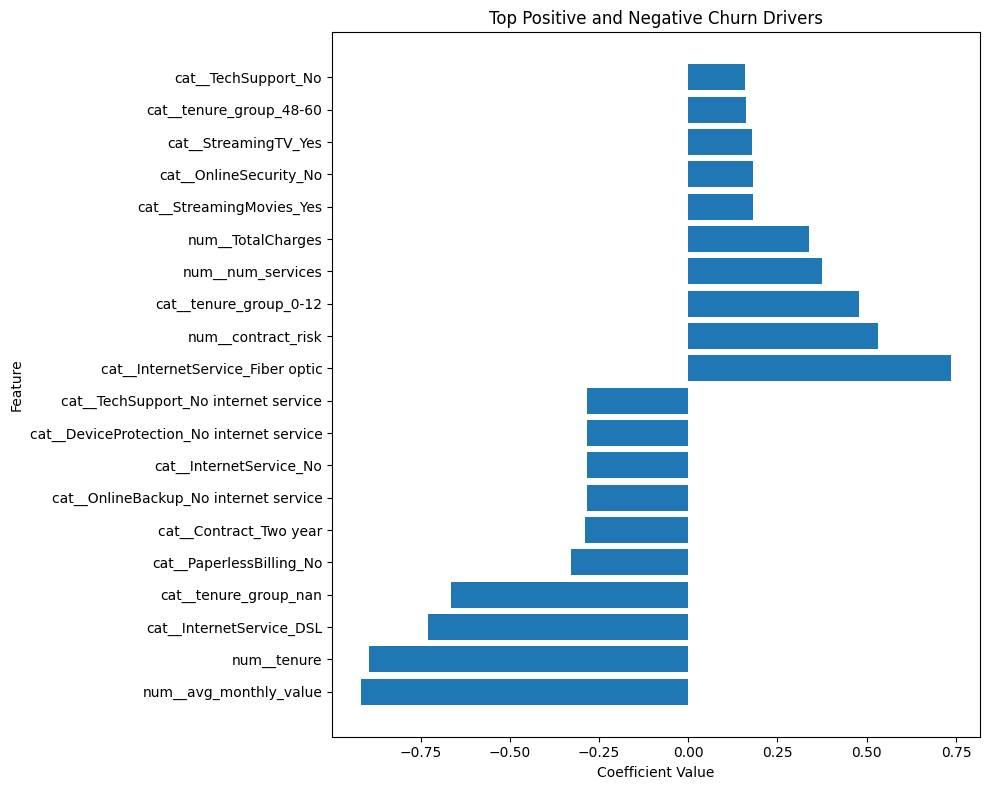

In [6]:
# plot coefficients
plot_top_coefficients(
    importance_df,
    top_n=10,
    save_path=FIGURES_DIR / "logistic_feature_importance.png"
)

In [ ]:
# display all coefficients
importance_df[["feature", "coefficient"]].head(30)

,feature,coefficient
52,num__avg_monthly_value,-0.915518
49,num__tenure,-0.893223
14,cat__InternetService_Fiber optic,0.734825
13,cat__InternetService_DSL,-0.730359
48,cat__tenure_group_nan,-0.664877
55,num__contract_risk,0.531382
43,cat__tenure_group_0-12,0.477445
53,num__num_services,0.375438
51,num__TotalCharges,0.337180
37,cat__PaperlessBilling_No,-0.327229


## Interpretation of Logistic Regression Coefficients

Positive coefficients increase the likelihood of churn.
Negative coefficients reduce the likelihood of churn.

Examples of likely positive churn drivers:
- Month-to-month contracts
- Electronic check payment method
- Lack of online security
- Lack of tech support
- Higher monthly charges
- Short tenure / new customer status

Examples of likely retention drivers:
- Two-year contracts
- Longer tenure
- Protection/support services
- Lower-risk payment methods
- Higher service engagement

## Business Interpretation

The explainability analysis shows that churn is driven less by demographics and more by commercial and service-related factors.

Main churn drivers:
- Customers on month-to-month contracts are significantly more likely to churn
- Customers without support/protection services are more likely to leave
- Customers paying via electronic check show elevated churn risk
- Newer customers face a higher risk of leaving early

Retention levers:
- Encourage migration from month-to-month to annual contracts
- Bundle online security, device protection, and tech support
- Focus onboarding and retention efforts on new customers
- Investigate friction in electronic check payment journeys